# Neural Posterior Estimation with Deep Set Embedding

NPE that conditions on a **set** of K galaxy observations via a Deep Set encoder.
Given K observations $\{(X_k, \sigma_k)\}_{k=1}^K$ from a single field, learn:
$$q(\omega \mid \{X_k\}) \approx p(\omega \mid \{X_k\})$$
The Deep Set embedding is permutation-invariant and handles variable K via masked mean-pooling.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import zuko
import matplotlib as mpl
import matplotlib.pyplot as plt
import corner
from tqdm.notebook import tqdm

mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['legend.frameon'] = False

In [2]:
# --- config ---
DATA_FILE = '/Users/ch54662/data/px2cosmo/mock/mock_pop_N10000_k100_z9.v1.npy'
K_MAX     = 100   # pad all groups to this length
SEED      = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
    torch.cuda.manual_seed(SEED)
else:
    DEVICE = 'cpu'
DEVICE = 'cpu'
print(f'device: {DEVICE}')

device: cpu


## Load and group data

Each row is `[omega(4), X(2), sigma(2)]`. Consecutive rows with the same `omega` form a group of K observations from one simulated field.

In [3]:
_data   = np.load(DATA_FILE)
omegas_flat = _data[:, :4].astype(np.float32)   # (N_total, 4)  [alpha, beta, gamma, M_UV*]
Xs_flat     = _data[:, 4:6].astype(np.float32)  # (N_total, 2)  [z, M_UV]
sigs_flat   = _data[:, 6:].astype(np.float32)   # (N_total, 2)  [sig_z, sig_Muv]
obs_flat    = np.concatenate([Xs_flat, sigs_flat], axis=1)  # (N_total, 4)

print(f'total rows: {_data.shape[0]}')
print(f'omega dim={omegas_flat.shape[1]}, obs dim={obs_flat.shape[1]}')

total rows: 917258
omega dim=4, obs dim=4


In [4]:
# detect consecutive groups with same omega
changed   = np.any(np.diff(omegas_flat, axis=0) != 0, axis=1)  # (N-1,)
bounds    = np.where(changed)[0] + 1
starts    = np.concatenate([[0], bounds])
ends      = np.concatenate([bounds, [len(omegas_flat)]])
counts    = (ends - starts).astype(int)             # K per group

N_omega = len(starts)
print(f'N_omega = {N_omega}')
print(f'K: min={counts.min()}, median={int(np.median(counts))}, max={counts.max()}')
print(f'groups with K={K_MAX}: {(counts == K_MAX).sum()}')

N_omega = 10000
K: min=7, median=100, max=100
groups with K=100: 8272


In [5]:
# build padded arrays: (N_omega, K_MAX, 4) and mask (N_omega, K_MAX)
obs_padded = np.zeros((N_omega, K_MAX, obs_flat.shape[1]), dtype=np.float32)
mask_np    = np.zeros((N_omega, K_MAX), dtype=bool)
omega_np   = np.zeros((N_omega, omegas_flat.shape[1]), dtype=np.float32)
k_np       = counts.copy()

for i, (s, k) in enumerate(zip(starts, counts)):
    k_use               = min(k, K_MAX)
    obs_padded[i, :k_use] = obs_flat[s:s + k_use]
    mask_np[i, :k_use]   = True
    omega_np[i]          = omegas_flat[s]

print('obs_padded:', obs_padded.shape)
print('mask:      ', mask_np.shape)
print('omega:     ', omega_np.shape)

obs_padded: (10000, 100, 4)
mask:       (10000, 100)
omega:      (10000, 4)


## Normalize inputs

In [6]:
# compute stats on valid (non-padded) observations only
valid_obs  = obs_flat  # all flat rows are real observations
obs_mean   = valid_obs.mean(0).astype(np.float32)
obs_std    = valid_obs.std(0).astype(np.float32)

omega_mean = omega_np.mean(0)
omega_std  = omega_np.std(0)

obs_norm   = (obs_padded - obs_mean) / obs_std     # padded zeros become ~-obs_mean/obs_std
omega_norm = (omega_np - omega_mean) / omega_std

# the padded zero entries won't affect mean-pooling because the mask zeroes them out
print('omega mean:', omega_mean)
print('omega std: ', omega_std)
print('obs mean:  ', obs_mean)
print('obs std:   ', obs_std)

omega mean: [ -1.7002975   -1.602136    -0.14953192 -19.488573  ]
omega std:  [0.17110398 0.23046005 0.14448859 1.4445693 ]
obs mean:   [  8.598462   -17.910387     0.5147339    0.25483283]
obs std:    [0.9396263  1.0380417  0.2799773  0.14141877]


## Train / validation split

In [7]:
rng   = np.random.default_rng(SEED)
idx   = rng.permutation(N_omega)
N_val = max(500, int(0.1 * N_omega))
N_train = N_omega - N_val

train_idx = idx[:N_train]
val_idx   = idx[N_train:]

def to_dev(arr):
    return torch.tensor(arr).to(DEVICE)

omega_train = to_dev(omega_norm[train_idx])    # (N_train, 4)
obs_train   = to_dev(obs_norm[train_idx])      # (N_train, K_MAX, 4)
mask_train  = to_dev(mask_np[train_idx])       # (N_train, K_MAX) bool

omega_val   = to_dev(omega_norm[val_idx])
obs_val     = to_dev(obs_norm[val_idx])
mask_val    = to_dev(mask_np[val_idx])

print(f'train: {N_train}, val: {N_val}')

train: 9000, val: 1000


## Deep Set NPE

Architecture:
- **$\phi$** (element-wise MLP): maps each observation $(X_k, \sigma_k) \to \mathbb{R}^{d_\phi}$
- **Aggregation**: masked mean over K observations (permutation invariant)
- **$\rho$** (post-aggregation MLP): maps pooled representation $\to$ embedding
- **NSF** (Neural Spline Flow): models $q(\omega \mid \text{embedding})$

In [8]:
class DeepSetEncoder(nn.Module):
    def __init__(self, d_obs=4, d_phi=128, d_emb=64):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(d_obs, d_phi), nn.GELU(),
            nn.Linear(d_phi, d_phi), nn.GELU(),
            nn.Linear(d_phi, d_phi),
        )
        self.rho = nn.Sequential(
            nn.Linear(d_phi, d_phi), nn.GELU(),
            nn.Linear(d_phi, d_emb),
        )

    def forward(self, x, mask):
        # x:    (batch, K_max, d_obs)
        # mask: (batch, K_max) bool  — True for real observations
        h = self.phi(x)                                 # (batch, K_max, d_phi)
        h = h * mask.unsqueeze(-1)                      # zero out padding
        n = mask.sum(dim=1, keepdim=True).float()       # (batch, 1)
        h = h.sum(dim=1) / n.clamp(min=1)              # (batch, d_phi)  masked mean
        return self.rho(h)                              # (batch, d_emb)


class DeepSetNPE(nn.Module):
    def __init__(self, d_theta=4, d_obs=4, d_phi=128, d_emb=64,
                 n_transforms=6, n_bins=8, hidden_features=(128, 128)):
        super().__init__()
        self.encoder = DeepSetEncoder(d_obs, d_phi, d_emb)
        self.flow    = zuko.flows.NSF(
            features         = d_theta,
            context          = d_emb,
            bins             = n_bins,
            transforms       = n_transforms,
            hidden_features  = list(hidden_features),
        )

    def log_prob(self, theta, obs, mask):
        emb = self.encoder(obs, mask)           # (batch, d_emb)
        return self.flow(emb).log_prob(theta)   # (batch,)

    def sample(self, obs_single, mask_single, n_samples=2000):
        # obs_single:  (K_max, d_obs)
        # mask_single: (K_max,) bool
        emb = self.encoder(obs_single.unsqueeze(0), mask_single.unsqueeze(0))  # (1, d_emb)
        return self.flow(emb).sample((n_samples,)).squeeze(1)                  # (n_samples, d_theta)


model = DeepSetNPE().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'trainable parameters: {n_params:,}')

trainable parameters: 281,704


## Training

In [9]:
BATCH_SIZE  = 256
N_EPOCHS    = 200
LR          = 3e-4
PATIENCE    = 20

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

train_losses, val_losses = [], []
best_val     = np.inf
best_state   = None
no_improve   = 0

for epoch in tqdm(range(N_EPOCHS), desc='epochs'):
    model.train()
    perm         = torch.randperm(N_train, device=DEVICE)
    batch_losses = []

    for i in range(0, N_train, BATCH_SIZE):
        bi   = perm[i : i + BATCH_SIZE]
        loss = -model.log_prob(omega_train[bi], obs_train[bi], mask_train[bi]).mean()
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        batch_losses.append(loss.item())

    scheduler.step()
    train_losses.append(float(np.mean(batch_losses)))

    model.eval()
    with torch.no_grad():
        val_loss = -model.log_prob(omega_val, obs_val, mask_val).mean().item()
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 20 == 0:
        print(f'epoch {epoch+1:4d}  train={train_losses[-1]:.4f}  val={val_loss:.4f}  '
              f'lr={optimizer.param_groups[0]["lr"]:.2e}')

    if no_improve >= PATIENCE:
        print(f'early stop at epoch {epoch + 1}')
        break

# restore best weights
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
print(f'best val loss: {best_val:.4f}')

epochs:   0%|          | 0/200 [00:00<?, ?it/s]

epoch   20  train=2.8738  val=2.9750  lr=2.93e-04
epoch   40  train=2.7592  val=2.8643  lr=2.71e-04
epoch   60  train=2.6134  val=2.8029  lr=2.38e-04
epoch   80  train=2.5670  val=2.7990  lr=1.96e-04
early stop at epoch 87
best val loss: 2.7771


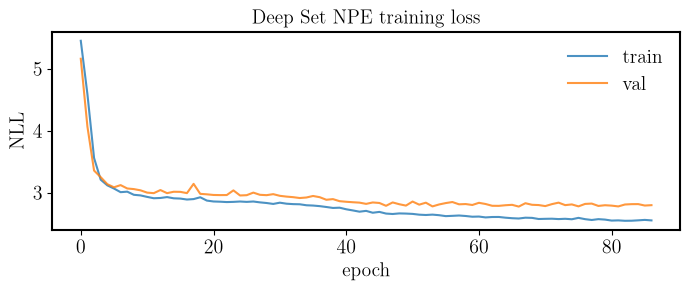

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses, label='train', alpha=0.8)
ax.plot(val_losses,   label='val',   alpha=0.8)
ax.set_xlabel('epoch', fontsize=14)
ax.set_ylabel('NLL', fontsize=14)
ax.legend(fontsize=14)
ax.set_title('Deep Set NPE training loss', fontsize=14)
plt.tight_layout()
plt.show()

## Save model

In [11]:
import os
save_dir = '/Users/ch54662/data/px2cosmo/mock/ndes/npe_deepset_z9'
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'model_state': {k: v.cpu() for k, v in model.state_dict().items()},
    'omega_mean':  omega_mean,
    'omega_std':   omega_std,
    'obs_mean':    obs_mean,
    'obs_std':     obs_std,
    'K_MAX':       K_MAX,
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'best_val':     best_val,
}, os.path.join(save_dir, 'npe_deepset_z9.0.pt'))
print('saved to', save_dir)

saved to /Users/ch54662/data/px2cosmo/mock/ndes/npe_deepset_z9


## Posterior validation

Draw posterior samples for several held-out test cases and overlay the true omega.

[ -1.5503393  -1.8545135  -0.1692914 -18.824566 ]
[ -1.493936    -1.4503342   -0.27221513 -20.308     ]
[ -1.4715445   -1.9134763   -0.26043528 -21.959702  ]
[ -1.4892234   -1.8788476   -0.06689083 -17.84507   ]
[ -1.5047591   -1.873234    -0.39165643 -19.608437  ]


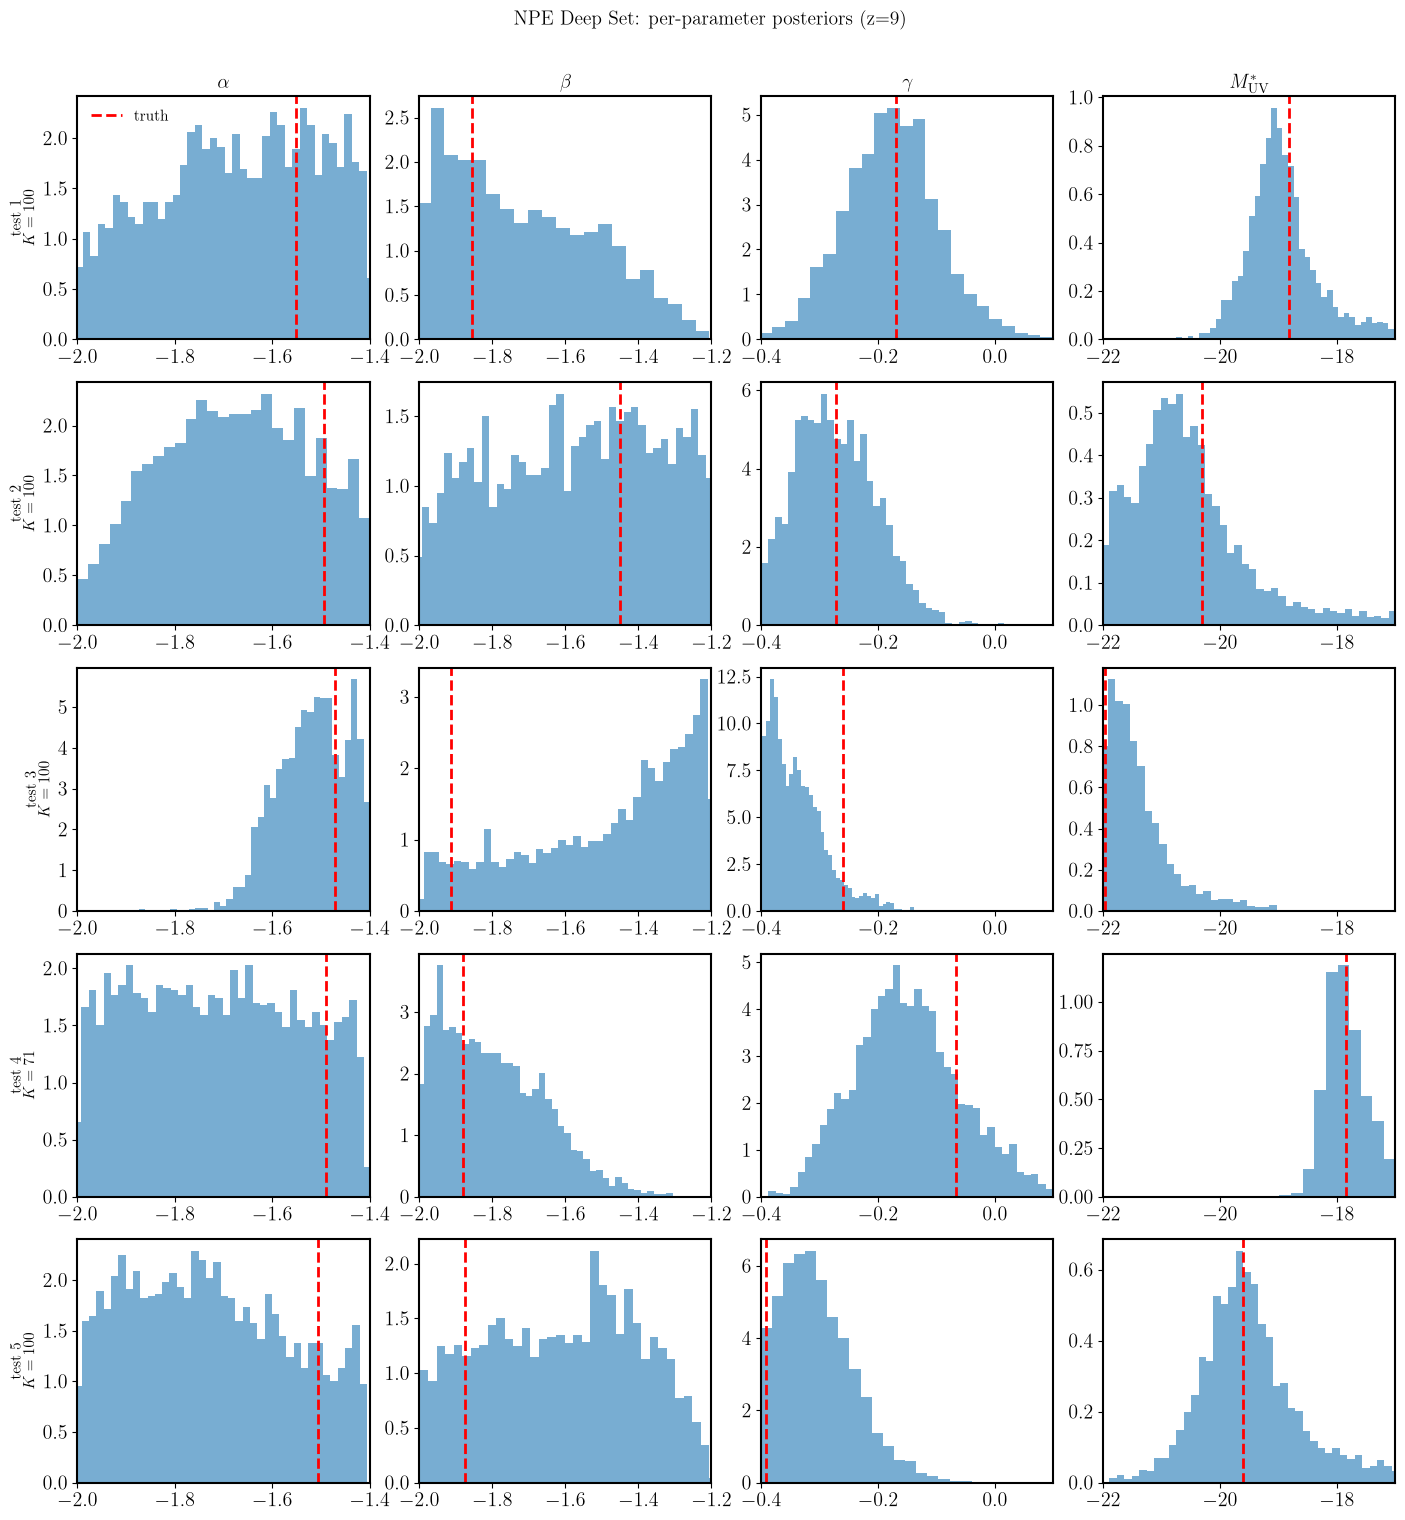

In [12]:
OMEGA_LABELS  = [r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$']
OMEGA_RANGES  = [(-2.0, -1.4), (-2.0, -1.2), (-0.4, 0.1), (-22., -17.)]

model.eval()
rng_test = np.random.default_rng(0)
test_cases = rng_test.choice(N_val, size=5, replace=False)

fig, axes = plt.subplots(len(test_cases), 4, figsize=(14, 3 * len(test_cases)))

for row, tc in enumerate(test_cases):
    with torch.no_grad():
        samples_norm = model.sample(obs_val[tc], mask_val[tc], n_samples=3000).cpu().numpy()
    samples = samples_norm * omega_std + omega_mean
    omega_true = omega_val[tc].cpu().numpy() * omega_std + omega_mean
    print(omega_true)
    for col in range(4):
        ax = axes[row, col]
        ax.hist(samples[:, col], bins=40, density=True, color='C0', alpha=0.6)
        ax.axvline(omega_true[col], color='r', lw=2, ls='--', label='truth')
        ax.set_xlim(OMEGA_RANGES[col])
        if row == 0:
            ax.set_title(OMEGA_LABELS[col], fontsize=14)
        if col == 0:
            K_obs = int(mask_val[tc].sum().cpu())
            ax.set_ylabel(f'test {row+1}\n$K={K_obs}$', fontsize=11)
        if row == 0 and col == 0:
            ax.legend(fontsize=11)

plt.suptitle('NPE Deep Set: per-parameter posteriors (z=9)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

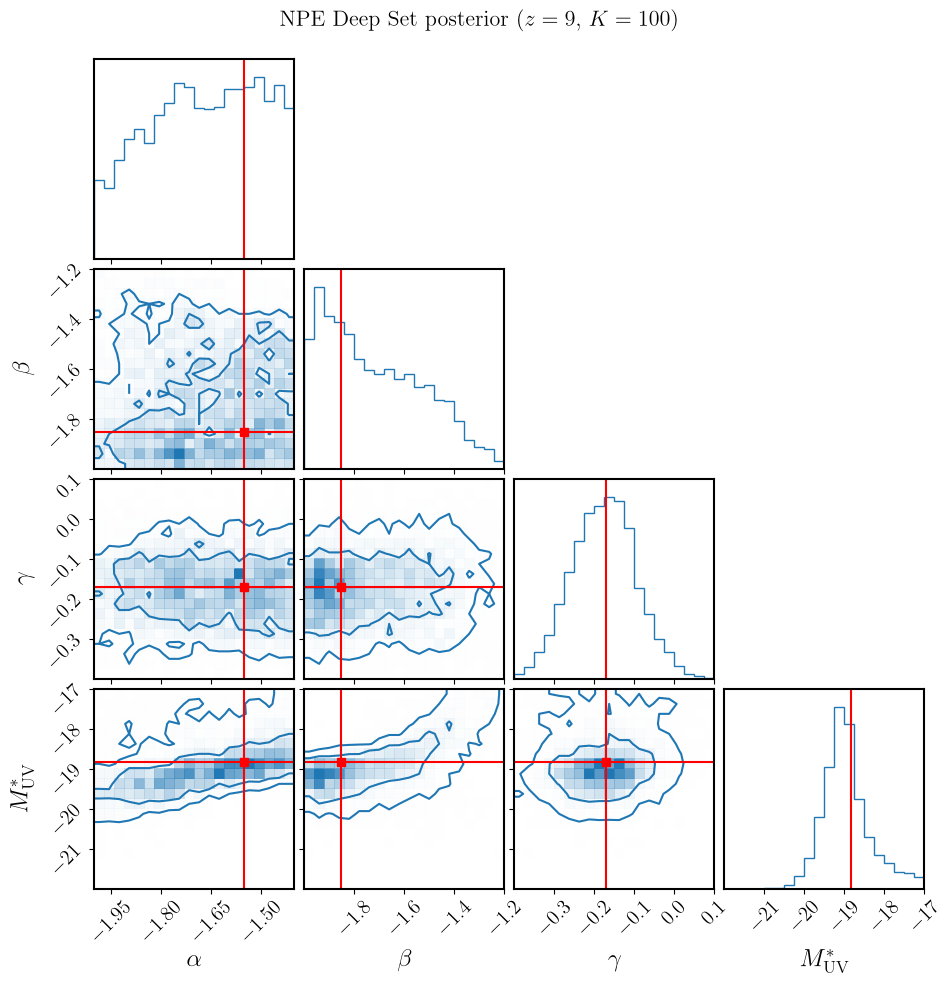

In [13]:
# full corner plot for one test case
tc = test_cases[0]
with torch.no_grad():
    samples_norm = model.sample(obs_val[tc], mask_val[tc], n_samples=5000).cpu().numpy()
samples    = samples_norm * omega_std + omega_mean
omega_true = omega_val[tc].cpu().numpy() * omega_std + omega_mean

K_obs = int(mask_val[tc].sum().cpu())

fig = corner.corner(
    samples,
    labels   = OMEGA_LABELS,
    range    = OMEGA_RANGES,
    truths   = omega_true,
    color    = 'C0',
    hist_kwargs = {'density': True},
    levels   = [0.68, 0.95],
    plot_datapoints = False,
    label_kwargs = {'fontsize': 18},
    truth_color  = 'r',
)
fig.suptitle(f'NPE Deep Set posterior ($z=9$, $K={K_obs}$)', fontsize=16, y=1.01)
plt.show()

## Expected coverage (rank-based)

For a well-calibrated posterior, the rank of the true value in the set of posterior samples should be uniform over [0, 1]. We check this per parameter.

coverage:   0%|          | 0/500 [00:00<?, ?it/s]

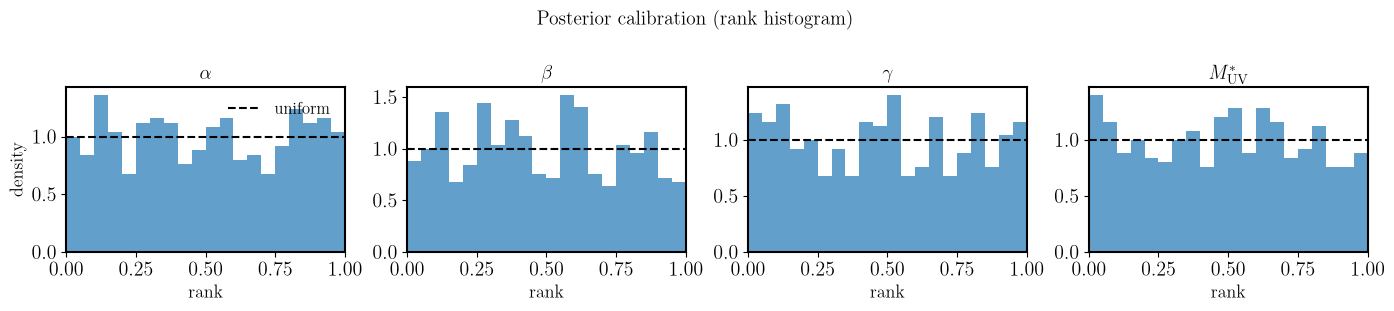

In [14]:
N_COVERAGE = min(500, N_val)
N_SAMPLES  = 500

cov_idx    = rng_test.choice(N_val, size=N_COVERAGE, replace=False)
ranks      = np.zeros((N_COVERAGE, 4))

model.eval()
for i, ci in enumerate(tqdm(cov_idx, desc='coverage')):
    with torch.no_grad():
        s_norm = model.sample(obs_val[ci], mask_val[ci], n_samples=N_SAMPLES).cpu().numpy()
    s    = s_norm * omega_std + omega_mean
    true = omega_val[ci].cpu().numpy() * omega_std + omega_mean
    ranks[i] = (s < true).mean(axis=0)  # fraction of samples below truth = rank

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for j, ax in enumerate(axes):
    ax.hist(ranks[:, j], bins=20, density=True, color='C0', alpha=0.7)
    ax.axhline(1.0, color='k', ls='--', lw=1.5, label='uniform')
    ax.set_xlim(0, 1)
    ax.set_xlabel('rank', fontsize=13)
    ax.set_title(OMEGA_LABELS[j], fontsize=14)
    if j == 0:
        ax.set_ylabel('density', fontsize=13)
        ax.legend(fontsize=12)

plt.suptitle('Posterior calibration (rank histogram)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Effect of K on posterior width

With Deep Sets, we can naturally evaluate the posterior for different numbers of observations. Here we subsample the observations for a single field and check how the posterior tightens.

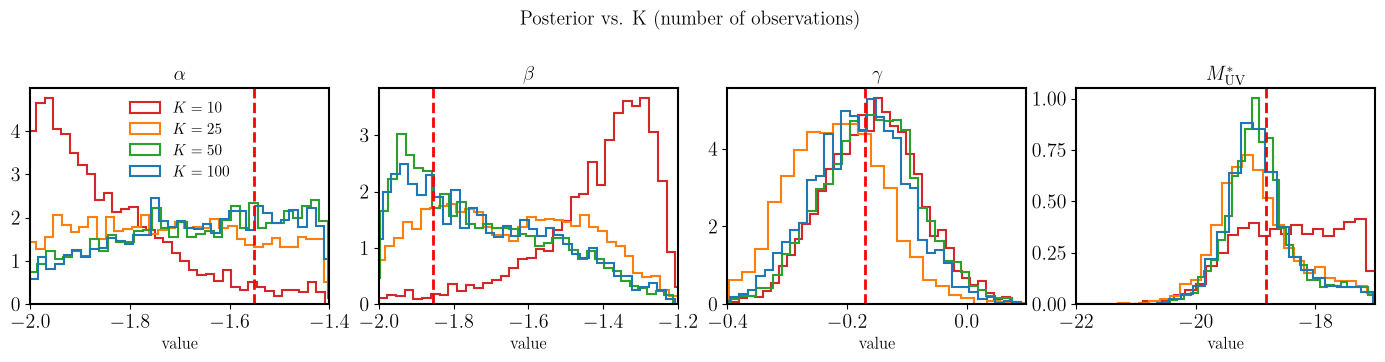

In [15]:
tc    = test_cases[0]
obs_t = obs_val[tc].cpu()          # (K_MAX, 4)
msk_t = mask_val[tc].cpu()         # (K_MAX,) bool
real_indices = torch.where(msk_t)[0]
K_real = real_indices.shape[0]
omega_true = omega_val[tc].cpu().numpy() * omega_std + omega_mean

K_vals = [10, 25, 50, K_real]
colors = ['C3', 'C1', 'C2', 'C0']

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
model.eval()

for k_sub, color in zip(K_vals, colors):
    sub_idx = real_indices[:k_sub]
    obs_sub = torch.zeros_like(obs_t)
    obs_sub[:k_sub] = obs_t[sub_idx]
    msk_sub = torch.zeros_like(msk_t)
    msk_sub[:k_sub] = True

    with torch.no_grad():
        s_norm = model.sample(obs_sub.to(DEVICE), msk_sub.to(DEVICE), n_samples=3000).cpu().numpy()
    s = s_norm * omega_std + omega_mean

    for j, ax in enumerate(axes):
        ax.hist(s[:, j], bins=35, density=True, histtype='step',
                color=color, lw=1.5, label=f'$K={k_sub}$')

for j, ax in enumerate(axes):
    ax.axvline(omega_true[j], color='r', lw=2, ls='--')
    ax.set_xlim(OMEGA_RANGES[j])
    ax.set_title(OMEGA_LABELS[j], fontsize=14)
    ax.set_xlabel('value', fontsize=12)

axes[0].legend(fontsize=11)
plt.suptitle('Posterior vs. K (number of observations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Inference on mock observations

Apply the trained model to the actual mock dataset: `X_obs_z9` (1542 observed galaxies at $z\sim9$).
Because the model was trained with $K=100$, we shuffle the observations and batch them into
non-overlapping chunks of $K_{\rm MAX}=100$, obtaining one posterior per batch.
Shuffling removes any ordering in the catalogue before splitting.

In [16]:
omega_true_full = np.load('/Users/ch54662/data/px2cosmo/mock/omega_true.npy')
X_obs_z9        = np.load('/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy').astype(np.float32)

# model infers first 4 params; phi_amp (index 4) was fixed during simulation
omega_true_4 = omega_true_full[:4]
print('omega_true (4 inferred):', omega_true_4)
print('X_obs_z9 shape:', X_obs_z9.shape, '  columns: [z, M_UV, sig_z, sig_Muv]')

# shuffle to remove any ordering in the catalogue before batching
rng_obs  = np.random.default_rng(0)
shuf_idx = rng_obs.permutation(len(X_obs_z9))
X_shuf   = X_obs_z9[shuf_idx]                  # (1542, 4) shuffled
X_norm   = (X_shuf - obs_mean) / obs_std        # normalise with training stats

N_obs     = len(X_shuf)
N_batches = N_obs // K_MAX
print(f'N_obs={N_obs}, K_MAX={K_MAX} -> {N_batches} non-overlapping batches '
      f'({N_obs - N_batches * K_MAX} leftover observations dropped)')

omega_true (4 inferred): [ -1.65  -1.5   -0.2  -20.  ]
X_obs_z9 shape: (1542, 4)   columns: [z, M_UV, sig_z, sig_Muv]
N_obs=1542, K_MAX=100 -> 15 non-overlapping batches (42 leftover observations dropped)


In [17]:
model.eval()
batch_samples = []   # list of N_batches arrays, each (N_post, 4)

for b in range(N_batches):
    obs_b = X_norm[b * K_MAX : (b + 1) * K_MAX]          # (K_MAX, 4)
    obs_t = torch.tensor(obs_b).to(DEVICE)                # all real — mask is all True
    msk_t = torch.ones(K_MAX, dtype=torch.bool, device=DEVICE)

    with torch.no_grad():
        s_norm = model.sample(obs_t, msk_t, n_samples=3000).cpu().numpy()
    batch_samples.append(s_norm * omega_std + omega_mean)

print(f'drew {N_batches} posteriors, {batch_samples[0].shape[0]} samples each')

drew 15 posteriors, 3000 samples each


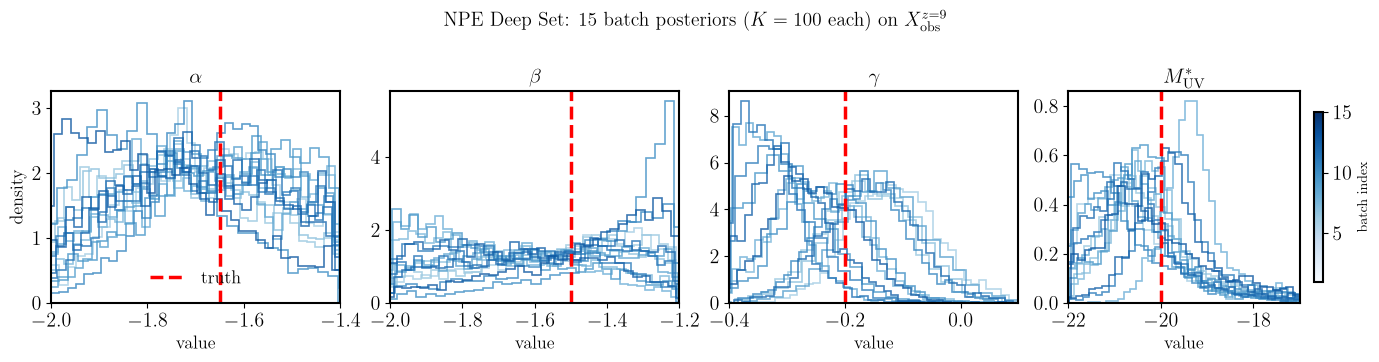

In [18]:
# per-parameter marginals: all batch posteriors overlaid, coloured by batch index
colors = plt.cm.Blues(np.linspace(0.35, 0.85, N_batches))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for b, s in enumerate(batch_samples):
    for j, ax in enumerate(axes):
        ax.hist(s[:, j], bins=35, density=True, histtype='step',
                color=colors[b], lw=1.2, alpha=0.8)

for j, ax in enumerate(axes):
    ax.axvline(omega_true_4[j], color='r', lw=2.5, ls='--', label='truth')
    ax.set_xlim(OMEGA_RANGES[j])
    ax.set_title(OMEGA_LABELS[j], fontsize=15)
    ax.set_xlabel('value', fontsize=13)

axes[0].set_ylabel('density', fontsize=13)
axes[0].legend(fontsize=13)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=1, vmax=N_batches))
sm.set_array([])
fig.colorbar(sm, ax=axes[-1], label='batch index', shrink=0.8)

plt.suptitle(
    rf'NPE Deep Set: {N_batches} batch posteriors ($K={K_MAX}$ each) on $X_{{\rm obs}}^{{z=9}}$',
    fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

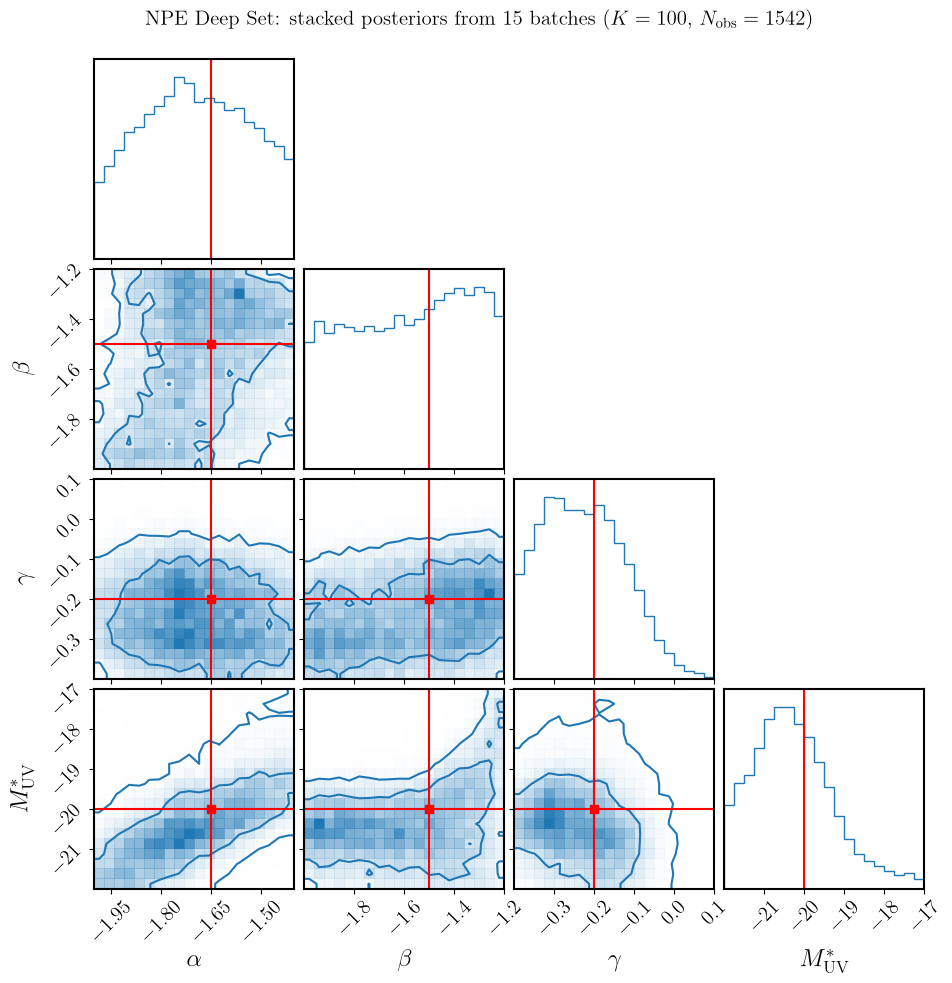

In [19]:
# corner plot: stack all batch samples (mixture of batch posteriors)
all_samples = np.concatenate(batch_samples, axis=0)   # (N_batches * 3000, 4)

fig = corner.corner(
    all_samples,
    labels          = OMEGA_LABELS,
    range           = OMEGA_RANGES,
    truths          = omega_true_4,
    color           = 'C0',
    hist_kwargs     = {'density': True},
    levels          = [0.68, 0.95],
    plot_datapoints = False,
    label_kwargs    = {'fontsize': 18},
    truth_color     = 'r',
)
fig.suptitle(
    rf'NPE Deep Set: stacked posteriors from {N_batches} batches ($K={K_MAX}$, $N_{{\rm obs}}={N_obs}$)',
    fontsize=15, y=1.01)
plt.show()

## Joint posterior via emcee

Each batch $b$ gives an NPE posterior $q(\omega \mid X_b) \approx p(\omega \mid X_b)$.
The joint posterior over all $B$ i.i.d. batches is

$$p(\omega \mid X_1,\ldots,X_B) \;\propto\; p(\omega)^{1-B} \prod_{b=1}^B q(\omega \mid X_b)$$

For a uniform prior $p(\omega)$ the $p(\omega)^{1-B}$ factor is a constant, so the unnormalised log-posterior reduces to a prior bounds check plus $\sum_b \log q(\omega \mid X_b)$.

The encoder embeddings are fixed (data is fixed), so we pre-compute them once and only run the flow at each MCMC step — making the sampler fast.

In [20]:
# pre-compute encoder embeddings once — they are fixed for given observations
model.eval()
obs_stack_t = torch.tensor(
    np.stack([X_norm[b * K_MAX : (b + 1) * K_MAX] for b in range(N_batches)])
).to(DEVICE)                                                      # (B, K_MAX, 4)
msk_stack_t = torch.ones(N_batches, K_MAX, dtype=torch.bool, device=DEVICE)  # all real

with torch.no_grad():
    emb_stack = model.encoder(obs_stack_t, msk_stack_t)          # (B, d_emb)

print(f'pre-computed {N_batches} embeddings: {emb_stack.shape}')

pre-computed 15 embeddings: torch.Size([15, 64])


In [21]:
import emcee

# uniform prior bounds (inferred from training data statistics)
prior_low  = np.array([-2.0, -2.0, -0.4, -22.0], dtype=np.float32)
prior_high = np.array([-1.4, -1.2,  0.1, -17.0], dtype=np.float32)

def log_prob_joint(omega):
    omega = np.asarray(omega, dtype=np.float32)
    # uniform prior: reject out-of-bounds
    if np.any(omega < prior_low) or np.any(omega > prior_high):
        return -np.inf

    omega_n = (omega - omega_mean) / omega_std
    # repeat omega B times to evaluate all batches in one flow forward pass
    omega_t = (torch.tensor(omega_n, device=DEVICE)
                    .unsqueeze(0)
                    .expand(N_batches, -1))          # (B, 4)

    with torch.no_grad():
        log_q = model.flow(emb_stack).log_prob(omega_t)   # (B,)

    return log_q.sum().item()


ndim, nwalkers = 4, 32

# initialise walkers at the median of the stacked batch posteriors + tiny scatter
init = np.median(all_samples, axis=0).astype(np.float32)
p0   = init + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_joint)
_ = sampler.run_mcmc(p0, 5000, progress=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [05:03<00:00, 16.49it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 100;
tau: [467.08732335 414.09428944 219.69485285 516.58648233]


autocorrelation time per param: [467.1 414.1 219.7 516.6]
flat chain: (992, 4)  (after discard=1549, thin=109)
acceptance fraction: 0.312


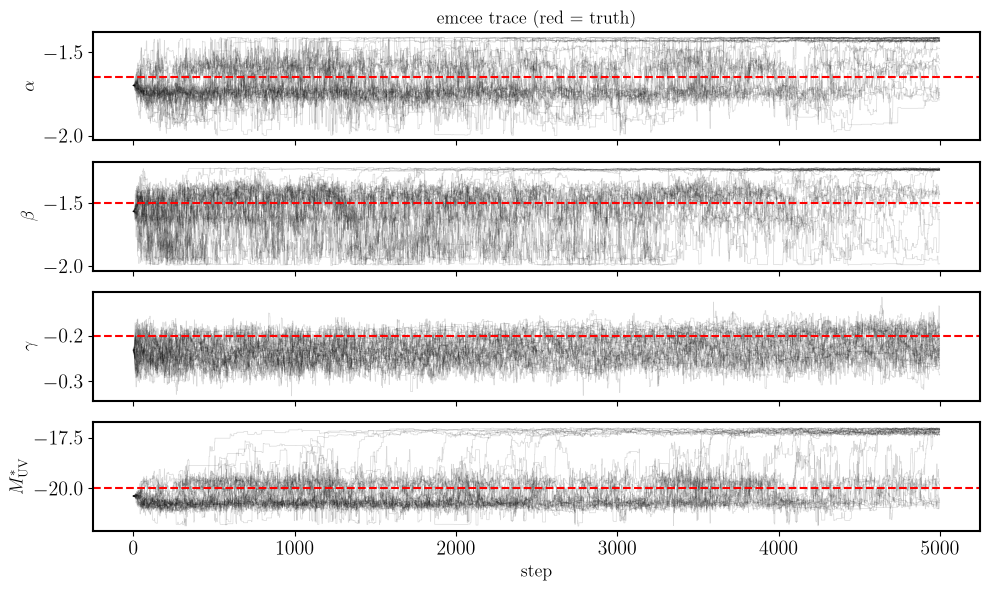

In [22]:
# chain diagnostics
try:
    tau = sampler.get_autocorr_time(quiet=True)
    print('autocorrelation time per param:', np.round(tau, 1))
    discard = int(3 * tau.max())
    thin    = max(1, int(tau.min() / 2))
except emcee.autocorr.AutocorrError:
    print('chain too short for autocorrelation estimate — using discard=500, thin=1')
    discard, thin = 500, 1

flat_chain = sampler.get_chain(discard=discard, thin=thin, flat=True)
print(f'flat chain: {flat_chain.shape}  (after discard={discard}, thin={thin})')
print(f'acceptance fraction: {sampler.acceptance_fraction.mean():.3f}')

# trace plot
fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)
raw_chain = sampler.get_chain()
for j, ax in enumerate(axes):
    ax.plot(raw_chain[:, :, j], color='k', alpha=0.15, lw=0.5)
    ax.axhline(omega_true_4[j], color='r', lw=1.5, ls='--')
    ax.set_ylabel(OMEGA_LABELS[j], fontsize=13)
axes[-1].set_xlabel('step', fontsize=13)
axes[0].set_title('emcee trace (red = truth)', fontsize=13)
plt.tight_layout()
plt.show()

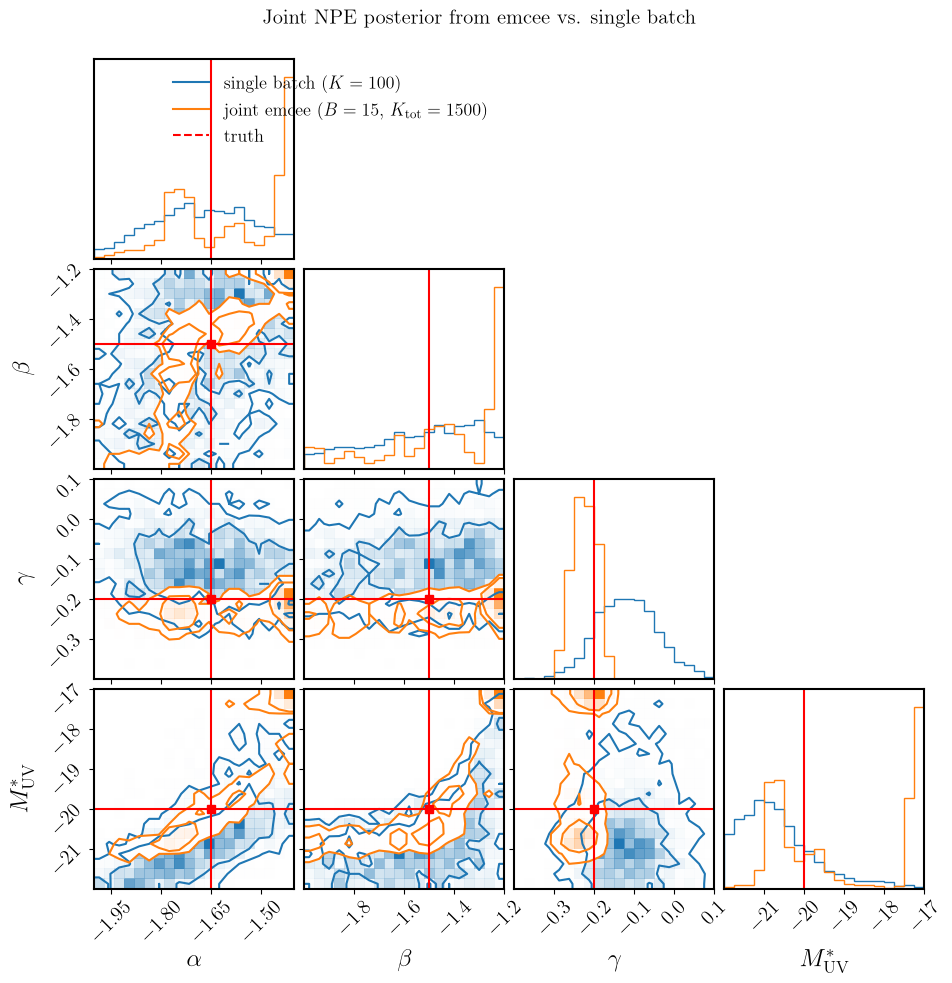

In [23]:
# corner: joint MCMC posterior vs. single-batch posterior vs. truth
single_batch = batch_samples[0]   # one K=100 batch for comparison

fig = corner.corner(
    single_batch,
    labels          = OMEGA_LABELS,
    range           = OMEGA_RANGES,
    color           = 'C0',
    hist_kwargs     = {'density': True},
    levels          = [0.68, 0.95],
    plot_datapoints = False,
    label_kwargs    = {'fontsize': 18},
)
corner.corner(
    flat_chain,
    labels          = OMEGA_LABELS,
    range           = OMEGA_RANGES,
    truths          = omega_true_4,
    color           = 'C1',
    hist_kwargs     = {'density': True},
    levels          = [0.68, 0.95],
    plot_datapoints = False,
    truth_color     = 'r',
    fig             = fig,
)

# legend
fig.axes[1].plot([], [], color='C0', label=f'single batch ($K={K_MAX}$)')
fig.axes[1].plot([], [], color='C1', label=f'joint emcee ($B={N_batches}$, $K_{{\\rm tot}}={N_batches*K_MAX}$)')
fig.axes[1].plot([], [], color='r',  ls='--', label='truth')
fig.axes[1].legend(fontsize=13, loc='upper right')

fig.suptitle('Joint NPE posterior from emcee vs. single batch', fontsize=15, y=1.01)
plt.show()